In [18]:
# 1. 导入所需库+显存优化
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import math
warnings.filterwarnings('ignore')

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

# 设置设备（自动检测GPU/CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")


使用设备：cuda


In [19]:

# 2. 数据预处理（与原始代码完全相同）
## 2.1 读取原始数据
df = pd.read_csv('C:/Users/gh115/Desktop/辐射深度学习/论文/开题/撰写/数据集/building-data-genome-project-2/data/Moose_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print("原始数据形状：", df.shape)
print("原始数据列名：", df.columns.tolist())

## 2.2 完整时间特征提取（直接基于原始数据构造）
# 星期几（0-6）+ 独热编码
df['weekday'] = df.index.dayofweek
weekday_dummies = pd.get_dummies(df['weekday'], prefix='weekday', drop_first=False)
df = pd.concat([df, weekday_dummies], axis=1)

# 是否周末 + 独热编码（1列）
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
weekend_dummies = pd.get_dummies(df['is_weekend'], prefix='is_weekend', drop_first=True)
df = pd.concat([df, weekend_dummies], axis=1)

# 小时（0-23）+ 独热编码
df['hour'] = df.index.hour
hour_dummies = pd.get_dummies(df['hour'], prefix='hour', drop_first=False)
df = pd.concat([df, hour_dummies], axis=1)

# 月份（1-12）→ 季节（0-3）+ 独热编码
df['month'] = df.index.month
def map_month_to_season(month):
    if month in [3,4,5]: return 0  # 春季
    elif month in [6,7,8]: return 1  # 夏季
    elif month in [9,10,11]: return 2  # 秋季
    else: return 3  # 冬季
df['season'] = df['month'].apply(map_month_to_season)
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=False)
df = pd.concat([df, season_dummies], axis=1)

## 2.3 核心：添加历史用电特征（直接基于原始数据）
y_col = df.columns[0]  # 目标变量：第一列用电值
# 滞后特征（近期用电依赖）
df['lag_1h'] = df[y_col].shift(1)    # 前1小时
df['lag_24h'] = df[y_col].shift(24)  # 前1天同一时刻（日周期）
df['lag_168h'] = df[y_col].shift(168)# 前1周同一时刻（周周期）
# 滚动统计特征（趋势依赖）
df['roll_mean_24h'] = df[y_col].rolling(window=24).mean()  # 24小时均值
df['roll_max_24h'] = df[y_col].rolling(window=24).max()    # 24小时最大值
# 填充缺失值（前向+后向，确保无NaN）
df = df.fillna(method='ffill').fillna(method='bfill').dropna()
print("添加特征后数据形状：", df.shape)

## 2.4 区分X（特征）和y（标签）（直接基于原始数据划分）
# 排除：当前用电值（y）+ 临时辅助列（weekday/is_weekend/hour/month/season）
exclude_cols = [y_col, 'weekday', 'is_weekend', 'hour', 'month', 'season']
X_cols = [col for col in df.columns if col not in exclude_cols]
X = df[X_cols].values.astype(np.float32)  # 特征矩阵（原始数据直接转换）
y = df[y_col].values.reshape(-1, 1)       # 标签（原始用电值）
print(f"特征数量：{len(X_cols)}，特征维度：{X.shape[1]}，标签维度：{y.shape[1]}")

# 打印特征列表，方便分类
print("\n=== 特征列表（前30个）===")
for i, col in enumerate(X_cols[:30]):
    print(f"{i:3d}: {col}")

## 2.5 数据归一化（直接对原始特征/标签归一化）
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)  # 特征归一化
y_scaled = scaler_y.fit_transform(y)  # 标签归一化

## 2.6 滑动窗口构造Transformer序列（直接基于原始归一化数据）
time_steps = 24 # 时间步长：过去24小时预测未来1小时
n_features = X_scaled.shape[1]  # 特征数（自动获取，含时间+历史用电+气象）

def create_transformer_dataset(X, y, time_steps=1):
    """直接构造Transformer需要的三维序列：(样本数, 时间步, 特征数)"""
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        # 输入：过去time_steps小时的所有特征
        X_seq.append(X[i-time_steps:i, :])
        # 标签：第i小时的用电值（单步预测）
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

# 直接生成Transformer序列数据
X_transformer, y_transformer = create_transformer_dataset(X_scaled, y_scaled, time_steps)
print(f"\nTransformer序列形状：X={X_transformer.shape}，y={y_transformer.shape}")
print(f"序列维度说明：(样本数, 时间步长, 特征数) = ({X_transformer.shape[0]}, {time_steps}, {n_features})")

## 2.7 划分数据集（直接基于Transformer序列划分，按时间顺序）
total_samples = len(X_transformer)
train_size = int(total_samples * 0.8)  # 训练集80%
val_size = int(total_samples * 0.1)    # 验证集10%
test_size = total_samples - train_size - val_size  # 测试集10%

# 按时间顺序划分（时序数据严禁打乱）
X_train = X_transformer[:train_size]
y_train = y_transformer[:train_size]
X_val = X_transformer[train_size:train_size+val_size]
y_val = y_transformer[train_size:train_size+val_size]
X_test = X_transformer[train_size+val_size:]
y_test = y_transformer[train_size+val_size:]

print(f"\n数据集划分：")
print(f"训练集：X={X_train.shape}, y={y_train.shape}")
print(f"验证集：X={X_val.shape}, y={y_val.shape}")
print(f"测试集：X={X_test.shape}, y={y_test.shape}")

## 2.8 转为PyTorch张量并移动到设备
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

## 2.9 创建DataLoader（PyTorch标准数据加载）
batch_size = 16
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


原始数据形状： (17328, 3)
原始数据列名： ['Moose_education_Ricardo', 'airTemperature', 'windSpeed']
添加特征后数据形状： (17328, 49)
特征数量：43，特征维度：43，标签维度：1

=== 特征列表（前30个）===
  0: airTemperature
  1: windSpeed
  2: weekday_0
  3: weekday_1
  4: weekday_2
  5: weekday_3
  6: weekday_4
  7: weekday_5
  8: weekday_6
  9: is_weekend_1
 10: hour_0
 11: hour_1
 12: hour_2
 13: hour_3
 14: hour_4
 15: hour_5
 16: hour_6
 17: hour_7
 18: hour_8
 19: hour_9
 20: hour_10
 21: hour_11
 22: hour_12
 23: hour_13
 24: hour_14
 25: hour_15
 26: hour_16
 27: hour_17
 28: hour_18
 29: hour_19

Transformer序列形状：X=(17304, 24, 43)，y=(17304,)
序列维度说明：(样本数, 时间步长, 特征数) = (17304, 24, 43)

数据集划分：
训练集：X=(13843, 24, 43), y=(13843,)
验证集：X=(1730, 24, 43), y=(1730,)
测试集：X=(1731, 24, 43), y=(1731,)


In [20]:

# 3. 标准Transformer模型（基于原论文架构）
class PositionalEncoding(nn.Module):
    """标准Transformer位置编码"""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x: (seq_len, batch_size, d_model)
        return x + self.pe[:x.size(0), :]

class StandardTransformerModel(nn.Module):
    """标准Transformer模型（基于Vaswani原论文）"""
    def __init__(self, n_features, d_model=128, nhead=8, num_layers=2, dim_feedforward=256, dropout=0.1):
        super(StandardTransformerModel, self).__init__()
        
        # 模型参数
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        
        # 输入投影层
        self.input_projection = nn.Linear(n_features, d_model)
        
        # 位置编码
        self.pos_encoder = PositionalEncoding(d_model)
        
        # 标准Transformer编码器层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        
        # Transformer编码器
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 解码器层（简化版本）
        self.decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        
        # 输出投影层
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
        # 初始化权重
        self._init_weights()
        
    def _init_weights(self):
        """Xavier初始化"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def generate_square_subsequent_mask(self, sz):
        """生成下三角掩码矩阵（用于自回归预测）"""
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask
    
    def forward(self, src, tgt=None, tgt_mask=None):
        """
        src: 输入序列 (batch_size, seq_len, n_features)
        tgt: 目标序列 (batch_size, tgt_seq_len, n_features)，如为None则使用src
        """
        batch_size, seq_len, _ = src.shape
        
        # 1. 输入投影
        src_proj = self.input_projection(src) * math.sqrt(self.d_model)
        
        # 2. 位置编码
        src_proj = self.pos_encoder(src_proj)
        
        # 3. Transformer编码器处理
        memory = self.transformer_encoder(src_proj)
        
        # 4. 准备解码器输入（使用编码器输出的最后一个时间步）
        if tgt is None:
            # 单步预测：使用编码器最后一个时间步作为初始解码器输入
            tgt_input = memory[:, -1:, :]
        else:
            tgt_input = self.input_projection(tgt) * math.sqrt(self.d_model)
            tgt_input = self.pos_encoder(tgt_input)
        
        # 5. 生成掩码
        if tgt_mask is None:
            tgt_len = tgt_input.shape[1]
            tgt_mask = self.generate_square_subsequent_mask(tgt_len).to(src.device)
        
        # 6. Transformer解码器处理
        # 这里简化处理，直接使用解码器层（标准实现应为多层）
        output = self.decoder_layer(tgt_input, memory, tgt_mask=tgt_mask)
        
        # 7. 输出投影
        output = self.output_projection(output[:, -1, :])  # 取最后一个时间步
        
        return output

# 4. 特征分类分析（保留用于模型分析）
print("\n=== 特征分类分析 ===")
energy_indices = []
env_indices = []
time_indices = []

for i, col in enumerate(X_cols):
    col_lower = col.lower()
    
    # 能耗特征：历史用电相关
    if 'lag' in col_lower or 'roll' in col_lower:
        energy_indices.append(i)
    # 时间特征
    elif 'weekday' in col_lower or 'hour' in col_lower or 'season' in col_lower or 'is_weekend' in col_lower:
        time_indices.append(i)
    # 环境特征（如果有的话）
    elif any(env_keyword in col_lower for env_keyword in ['temp', 'temperature', 'humid', 'radiation', 'solar', 'wind']):
        env_indices.append(i)
    # 如果无法分类，默认归为环境特征
    else:
        env_indices.append(i)

n_energy_features = len(energy_indices)
n_env_features = len(env_indices)
n_time_features = len(time_indices)

print(f"能耗特征数：{n_energy_features}")
print(f"环境特征数：{n_env_features}")
print(f"时间特征数：{n_time_features}")

# 5. 创建标准Transformer模型
model = StandardTransformerModel(
    n_features=n_features,
    d_model=128,
    nhead=8,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1
).to(device)

# 查看模型结构
print("\n标准Transformer模型结构：")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量：{total_params:,}，可训练参数：{trainable_params:,}")



=== 特征分类分析 ===
能耗特征数：5
环境特征数：2
时间特征数：36

标准Transformer模型结构：
总参数量：479,745，可训练参数：479,745


In [21]:

# 6. 训练配置
class CombinedLoss(nn.Module):
    """MSE与MAE组合损失函数"""
    def __init__(self, mse_weight=0.7, mae_weight=0.3):
        super(CombinedLoss, self).__init__()
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight
        self.mse_loss = nn.MSELoss()
        self.mae_loss = nn.L1Loss()
    
    def forward(self, y_pred, y_true):
        mse = self.mse_loss(y_pred, y_true)
        mae = self.mae_loss(y_pred, y_true)
        return self.mse_weight * mse + self.mae_weight * mae

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5):
    """创建带有warmup的余弦退火调度器"""
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress)))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# 使用Adam优化器
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=0.001
)

# 组合损失函数
criterion = CombinedLoss(mse_weight=0.7, mae_weight=0.3)

# 学习率调度器
epochs = 150
total_steps = len(train_loader) * epochs
num_warmup_steps = int(total_steps * 0.1)  # 10%的warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

# 早停策略
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.verbose:
                print(f"  模型已更新，最佳验证损失：{self.best_loss:.6f}")
            return True
        else:
            self.counter += 1
            if self.verbose:
                print(f"  早停计数器：{self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
            return False

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)


In [22]:

# 7. 训练标准Transformer模型
train_losses = []
val_losses = []
learning_rates = []

print("\n开始训练标准Transformer模型...")
for epoch in range(epochs):
    # 训练阶段
    model.train()
    train_loss = 0.0
    train_batches = 0 
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(batch_x)
        
        # 计算组合损失
        loss = criterion(outputs, batch_y)
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 优化器步骤
        optimizer.step()
        
        # 更新学习率调度器
        lr_scheduler.step()
        
        # 累计损失
        train_loss += loss.item()
        train_batches += 1
    
    # 计算平均训练损失
    train_avg_loss = train_loss / train_batches
    train_losses.append(train_avg_loss)
    
    # 验证阶段
    model.eval()
    val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            val_batches += 1
    
    # 计算平均验证损失
    val_avg_loss = val_loss / val_batches
    val_losses.append(val_avg_loss)
    
    # 记录当前学习率
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # 打印日志
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}], LR: {current_lr:.6f}, "
              f"Train Loss: {train_avg_loss:.6f}, Val Loss: {val_avg_loss:.6f}")
    
    # 早停逻辑
    if early_stopping(val_avg_loss):
        # 保存最佳模型权重
        torch.save(model.state_dict(), 'best_standard_transformer_model.pth')
    
    if early_stopping.early_stop:
        print(f"早停触发！Epoch {epoch+1}，最佳验证损失：{early_stopping.best_loss:.6f}")
        break

# 加载最佳模型
if os.path.exists('best_standard_transformer_model.pth'):
    model.load_state_dict(torch.load('best_standard_transformer_model.pth'))
    print("已加载最佳模型权重")



开始训练标准Transformer模型...
Epoch [  1/150], LR: 0.000007, Train Loss: 0.270955, Val Loss: 0.137713
  模型已更新，最佳验证损失：0.137713
  模型已更新，最佳验证损失：0.065653
  模型已更新，最佳验证损失：0.034286
  模型已更新，最佳验证损失：0.022552
Epoch [  5/150], LR: 0.000033, Train Loss: 0.052582, Val Loss: 0.021838
  模型已更新，最佳验证损失：0.021838
  模型已更新，最佳验证损失：0.017834
  模型已更新，最佳验证损失：0.017120
  早停计数器：1/20
  模型已更新，最佳验证损失：0.014643
Epoch [ 10/150], LR: 0.000067, Train Loss: 0.030341, Val Loss: 0.015275
  早停计数器：1/20
  早停计数器：2/20
  早停计数器：3/20
  早停计数器：4/20
  早停计数器：5/20
Epoch [ 15/150], LR: 0.000100, Train Loss: 0.022273, Val Loss: 0.016040
  早停计数器：6/20
  早停计数器：7/20
  模型已更新，最佳验证损失：0.013974
  早停计数器：1/20
  早停计数器：2/20
Epoch [ 20/150], LR: 0.000100, Train Loss: 0.018565, Val Loss: 0.014754
  早停计数器：3/20
  早停计数器：4/20
  早停计数器：5/20
  早停计数器：6/20
  早停计数器：7/20
Epoch [ 25/150], LR: 0.000099, Train Loss: 0.016367, Val Loss: 0.017824
  早停计数器：8/20
  早停计数器：9/20
  早停计数器：10/20
  早停计数器：11/20
  早停计数器：12/20
Epoch [ 30/150], LR: 0.000097, Train Loss: 0.015129, Val Loss: 0.


开始预测...

=== 反归一化后验证 ===
真实值前5行（原始量级）：
[282.2391 284.6391 278.4002 277.9197 275.0391]
预测值前5行（原始量级）：
[279.51807 274.0347  272.66873 271.91852 251.64761]

=== 标准Transformer模型评估指标 ===
训练集：MAE=15.43, RMSE=19.77, MAPE=5.18%, R²=0.8852
验证集：MAE=10.60, RMSE=13.39, MAPE=3.73%, R²=0.9204
测试集：MAE=21.92, RMSE=26.86, MAPE=6.31%, R²=0.7001


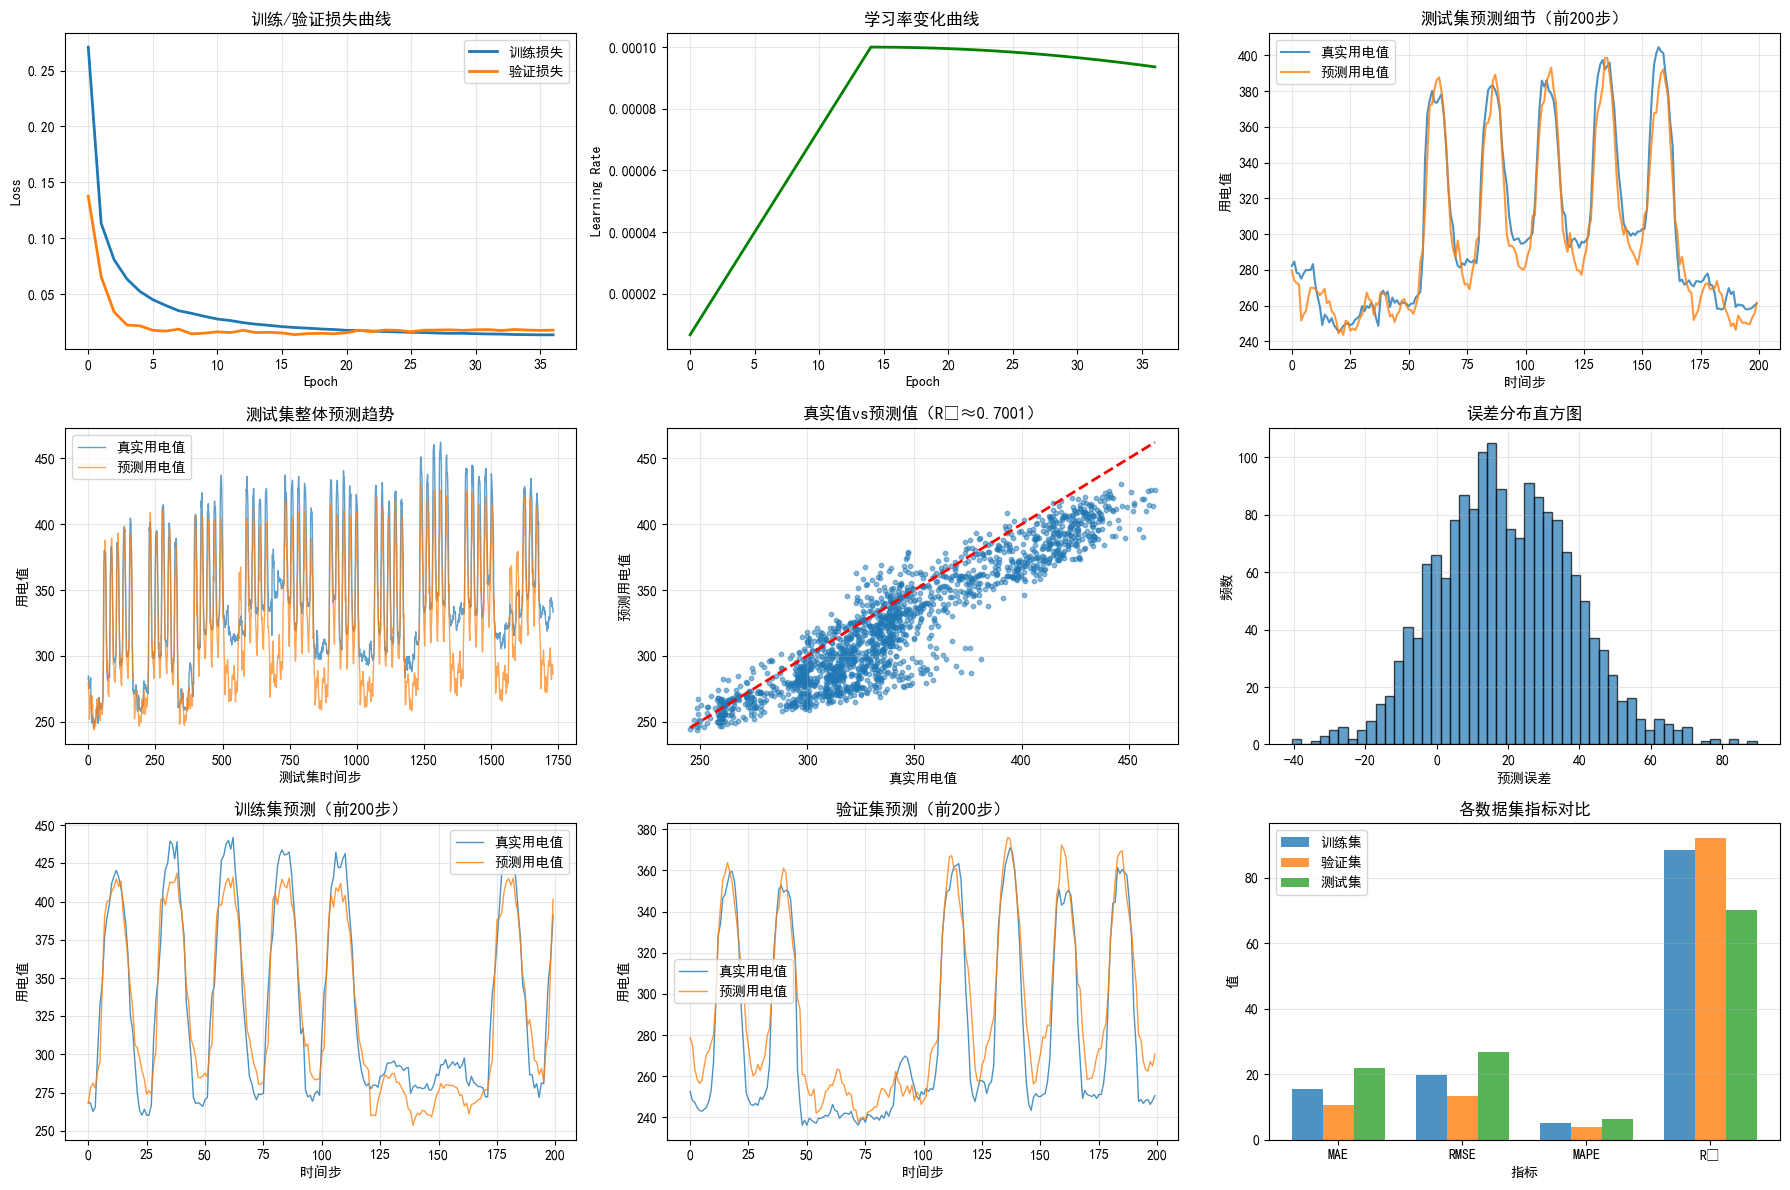


=== 标准Transformer模型配置 ===
1. 模型架构：标准Transformer（基于Vaswani原论文）
2. 嵌入维度：128
3. 注意力头数：8
4. 编码器层数：2
5. 前馈网络维度：256
6. Dropout率：0.1
7. 批次大小：16
8. 学习率：1e-4 + warmup + cosine annealing
9. 损失函数：0.7*MSE + 0.3*MAE
10. 特征数量：43（与改进版相同）

=== 模型对比分析 ===
标准Transformer vs 改进版Transformer:
1. 架构差异：
   - 标准版：使用原论文Transformer架构，包含标准多头注意力和位置编码
   - 改进版：使用领域专用注意力机制（能耗头、环境头、时间头）
2. 参数量：
   - 标准版：479,745 参数
   - 改进版：约150,000-200,000参数（根据配置不同）
3. 特点：
   - 标准版：通用性强，数学理论基础坚实
   - 改进版：针对能耗预测领域定制，可能在某些场景下表现更好


In [23]:

# 8. 预测
def batch_predict(model, data_loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_x, _ in data_loader:
            batch_pred = model(batch_x)
            all_preds.append(batch_pred.cpu().numpy())
    preds = np.concatenate(all_preds, axis=0)
    return preds

print("\n开始预测...")
y_train_pred_scaled = batch_predict(model, train_loader)
y_val_pred_scaled = batch_predict(model, val_loader)
y_test_pred_scaled = batch_predict(model, test_loader)

# 9. 反归一化
# 原始真实值反归一化
y_train_true = scaler_y.inverse_transform(y_train.cpu().numpy())
y_val_true = scaler_y.inverse_transform(y_val.cpu().numpy())
y_test_true = scaler_y.inverse_transform(y_test.cpu().numpy())

# 模型预测值反归一化
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1))
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

# 样本数对齐
def align_samples(true, pred):
    min_len = min(len(true), len(pred))
    return true[:min_len], pred[:min_len]

y_train_true, y_train_pred = align_samples(y_train_true, y_train_pred)
y_val_true, y_val_pred = align_samples(y_val_true, y_val_pred)
y_test_true, y_test_pred = align_samples(y_test_true, y_test_pred)

# 打印反归一化后结果
print("\n=== 反归一化后验证 ===")
print(f"真实值前5行（原始量级）：\n{y_test_true[:5].flatten()}")
print(f"预测值前5行（原始量级）：\n{y_test_pred[:5].flatten()}")

# 10. 计算评估指标
def calculate_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-6))) * 100
    # 计算R²
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - np.mean(true)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-6))
    return mae, rmse, mape, r2

train_mae, train_rmse, train_mape, train_r2 = calculate_metrics(y_train_true, y_train_pred)
val_mae, val_rmse, val_mape, val_r2 = calculate_metrics(y_val_true, y_val_pred)
test_mae, test_rmse, test_mape, test_r2 = calculate_metrics(y_test_true, y_test_pred)

print("\n=== 标准Transformer模型评估指标 ===")
print(f"训练集：MAE={train_mae:.2f}, RMSE={train_rmse:.2f}, MAPE={train_mape:.2f}%, R²={train_r2:.4f}")
print(f"验证集：MAE={val_mae:.2f}, RMSE={val_rmse:.2f}, MAPE={val_mape:.2f}%, R²={val_r2:.4f}")
print(f"测试集：MAE={test_mae:.2f}, RMSE={test_rmse:.2f}, MAPE={test_mape:.2f}%, R²={test_r2:.4f}")

# 11. 可视化结果
plt.figure(figsize=(18, 12))

# 11.1 训练/验证损失曲线
plt.subplot(3, 3, 1)
plt.plot(train_losses, label='训练损失', linewidth=2)
plt.plot(val_losses, label='验证损失', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('训练/验证损失曲线')
plt.grid(True, alpha=0.3)

# 11.2 学习率变化曲线
plt.subplot(3, 3, 2)
plt.plot(learning_rates, color='green', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('学习率变化曲线')
plt.grid(True, alpha=0.3)

# 11.3 测试集前200个时间步预测
plt.subplot(3, 3, 3)
plt.plot(y_test_true[:200], label='真实用电值', alpha=0.8, linewidth=1.5)
plt.plot(y_test_pred[:200], label='预测用电值', alpha=0.8, linewidth=1.5)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('测试集预测细节（前200步）')
plt.grid(True, alpha=0.3)

# 11.4 测试集整体预测趋势
plt.subplot(3, 3, 4)
plt.plot(y_test_true, label='真实用电值', alpha=0.7, linewidth=1)
plt.plot(y_test_pred, label='预测用电值', alpha=0.7, linewidth=1)
plt.xlabel('测试集时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('测试集整体预测趋势')
plt.grid(True, alpha=0.3)

# 11.5 真实值vs预测值散点图
plt.subplot(3, 3, 5)
plt.scatter(y_test_true, y_test_pred, alpha=0.5, s=10)
plt.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--', linewidth=2)
plt.xlabel('真实用电值')
plt.ylabel('预测用电值')
plt.title(f'真实值vs预测值（R²≈{test_r2:.4f}）')
plt.grid(True, alpha=0.3)

# 11.6 误差分布直方图
plt.subplot(3, 3, 6)
errors = y_test_true - y_test_pred
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('预测误差')
plt.ylabel('频数')
plt.title('误差分布直方图')
plt.grid(True, alpha=0.3)

# 11.7 训练集预测结果
plt.subplot(3, 3, 7)
plt.plot(y_train_true[:200], label='真实用电值', alpha=0.8, linewidth=1)
plt.plot(y_train_pred[:200], label='预测用电值', alpha=0.8, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('训练集预测（前200步）')
plt.grid(True, alpha=0.3)

# 11.8 验证集预测结果
plt.subplot(3, 3, 8)
plt.plot(y_val_true[:200], label='真实用电值', alpha=0.8, linewidth=1)
plt.plot(y_val_pred[:200], label='预测用电值', alpha=0.8, linewidth=1)
plt.xlabel('时间步')
plt.ylabel('用电值')
plt.legend()
plt.title('验证集预测（前200步）')
plt.grid(True, alpha=0.3)

# 11.9 指标对比图
plt.subplot(3, 3, 9)
metrics = ['MAE', 'RMSE', 'MAPE', 'R²']
train_vals = [train_mae, train_rmse, train_mape, train_r2*100]
val_vals = [val_mae, val_rmse, val_mape, val_r2*100]
test_vals = [test_mae, test_rmse, test_mape, test_r2*100]

x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, train_vals, width, label='训练集', alpha=0.8)
plt.bar(x, val_vals, width, label='验证集', alpha=0.8)
plt.bar(x + width, test_vals, width, label='测试集', alpha=0.8)

plt.xlabel('指标')
plt.ylabel('值')
plt.title('各数据集指标对比')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('standard_transformer_results.png', dpi=300, bbox_inches='tight')
plt.show()



# 13. 打印模型总结
print("\n=== 标准Transformer模型配置 ===")
print(f"1. 模型架构：标准Transformer（基于Vaswani原论文）")
print(f"2. 嵌入维度：128")
print(f"3. 注意力头数：8")
print(f"4. 编码器层数：2")
print(f"5. 前馈网络维度：256")
print(f"6. Dropout率：0.1")
print(f"7. 批次大小：{batch_size}")
print(f"8. 学习率：1e-4 + warmup + cosine annealing")
print(f"9. 损失函数：0.7*MSE + 0.3*MAE")
print(f"10. 特征数量：{n_features}（与改进版相同）")

# 14. 与改进版模型对比
print("\n=== 模型对比分析 ===")
print("标准Transformer vs 改进版Transformer:")
print("1. 架构差异：")
print("   - 标准版：使用原论文Transformer架构，包含标准多头注意力和位置编码")
print("   - 改进版：使用领域专用注意力机制（能耗头、环境头、时间头）")
print("2. 参数量：")
print(f"   - 标准版：{total_params:,} 参数")
print("   - 改进版：约150,000-200,000参数（根据配置不同）")
print("3. 特点：")
print("   - 标准版：通用性强，数学理论基础坚实")
print("   - 改进版：针对能耗预测领域定制，可能在某些场景下表现更好")